<a href="https://colab.research.google.com/github/DrDourado/ME_615_Spring_2026/blob/main/ME_615_Introduction_to_Obj_Detection_and_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook illustrates the basic concepts of object detection and transfer learning. In it the [Pascal VOC dataset](http://host.robots.ox.ac.uk/pascal/VOC/voc2007/) is used to demonstrate a object detection example through the concept of bounding boxes and the MobileNetV2 is tuned as a Feature Extractor.

In this notebook, will walk through the creation of a neural network capable of predicting both image classification and bounding box coordinates. Steps demonstrated in this notebook includes:

1. **Convolutional Neural Network (CNN) Architecture**: A simple CNN architecture is created using TensorFlow's Keras API. The architecture consists of convolutional layers followed by max-pooling layers and fully connected layers for image classification.
2. **Transfer Learning**: a machine learning technique where a pre-trained model—originally trained on a large dataset for a specific task—is adapted to a different but related task. Instead of training a model from scratch, transfer learning leverages the knowledge embedded in a well-trained model to improve efficiency and performance on a new problem.  
3. **Training the Model**: The model is trained using the Pascal VOC dataset. The loss function used for the classification task is sparse categorical crossentropy, and accuracy is used as the metric. For the regression problem related to obtaining the bounding boxes coordinates, mean-squared error is employed as the regression loss function.
4. **Visualizing Bounding Boxes After Training**: The trained models are used to make predictions on the validation set, and the predicted bounding boxes are visualized to assess the model's performance.

By going through this notebook, you should understand the basic workflow of building an object detection model.

### Object Detection Explained

Object detection is a computer vision task that involves identifying and locating objects within an image or video. Its main goal is to draw bounding boxes around all detected objects and determine their class labels. This process combines two primary components:

1.  **Object Classification:** This component is responsible for determining *what* an object is. For each detected object, a classification model assigns a label (e.g., "cat", "dog", "car").
2.  **Object Localization:** This component focuses on determining *where* an object is located within the image. It typically outputs the coordinates of a bounding box that tightly encloses the object, specifying its position and scale.

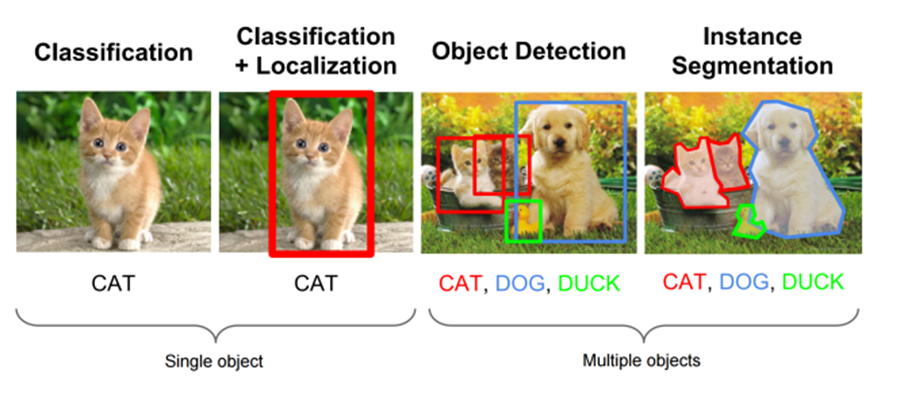

Applications in mechanical engineering include:

- Automated visual inspection of manufactured parts
- Crack or corrosion detection in infrastructure
- Tool tracking in robotic manufacturing
- Defect segmentation in additive manufacturing
- Surface damage detection in rotating machinery

Object Detection - Core Concepts:The detection model identifies **what objects exist in an image and where they are located**.

Usual outputs consists of:
- class label
- bounding box coordinates

A typical model contains two tasks:
- **Classification head** : Determines what object is present.
- **Localization head** : Predicts the bounding box coordinates (typically  x_center, y_center, width, height)

This often leads to a **branched neural network architecture**.

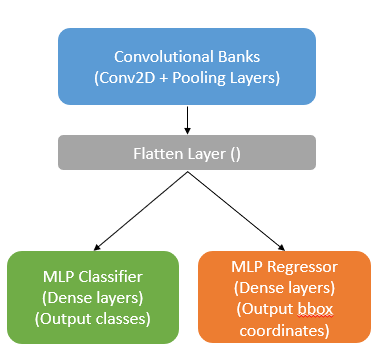

**When to use Transfer Learning?**

This approach is particularly useful when:

* The new dataset is small and insufficient for training a deep neural network from scratch.
* The computational resources are limited, making full model training impractical.
* The new task shares similarities with the original task (e.g., both involve object detection or classification of natural images).

**How Does Transfer Learning Work?**

1. Choose a Pre-trained Model:
* A deep neural network (CNN) trained on a large dataset (e.g., ImageNet) is selected.
* Examples of popular pre-trained models include VGG16, ResNet, MobileNet, EfficientNet, and Inception.

2. Freeze the Convolutional Base:

* The pre-trained model contains layers that have already learned general features like edges, shapes, and textures.
* These layers are frozen (i.e., their weights are not updated) to retain learned feature representations.

3. Add a Custom Output Layer:

* Since the pre-trained model was built for a different classification task (e.g., classifying 1000 ImageNet objects), the final dense layers are removed and replaced with new layers tailored to the new task.
* For object detection, two new output layers are added:
  * Classification Output: Predicts the object class using a softmax layer.
  * Bounding Box Output: Predicts bounding box coordinates using a regression layer.

4. Fine-tuning (Optional): In some cases, after training the new layers, a few deeper layers of the pre-trained model are unfrozen and fine-tuned on the new dataset to adapt features better.

**Advantages of Transfer Learning**

* Faster Training: The model learns quickly since most of the feature extraction is already done.
* Better Performance with Less Data: Pre-trained models generalize well, requiring fewer training samples.
* Reduces Overfitting: Since the model is pre-trained on a large dataset, it generalizes better to new tasks.

**Transfer Learning in Object Detection**: In this notebook, we use MobileNetV2 as the feature extractor. MobileNetV2 is lightweight and optimized for real-time applications, making it ideal for object detection on limited hardware.

Training CNNs from scratch requires millions of images.

Transfer learning allows models to reuse visual features learned on previous sets.

CNN layers learn progressively:

| Layer depth   | Learned features      |
| ------------- | --------------------- |
| Early layers  | edges and corners     |
| Middle layers | shapes and textures   |
| Deep layers   | semantic object parts |


Thus, in this notebook we'll implement a **conceptually simple detector**.

Architecture:

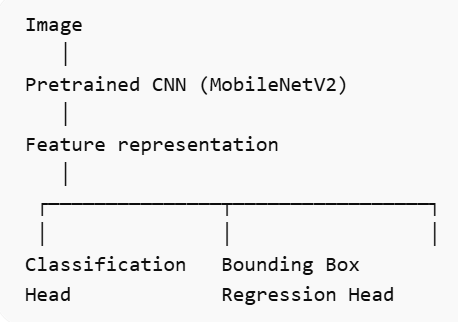

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

In [11]:
def draw_bounding_boxes(image, boxes, labels):
    image = np.array(image * 255, dtype=np.uint8)
    for box, label in zip(boxes, labels):
        ymin, xmin, ymax, xmax = box
        start_point = (int(xmin * image.shape[1]), int(ymin * image.shape[0]))
        end_point = (int(xmax * image.shape[1]), int(ymax * image.shape[0]))
        image = cv2.rectangle(image, start_point, end_point, (255, 0, 0), 2)
        cv2.putText(image, label, start_point, cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)
    plt.imshow(image)
    plt.axis("off")
    plt.show()

# Transfer Learning: Load pre-trained MobileNetV2 as a feature extractor
def load_pretrained_model(height,width,channels):
    base_model = tf.keras.applications.MobileNetV2(input_shape=(height, width, channels), include_top=False, weights='imagenet')
    base_model.trainable = False # Freeze convolutional layers

    image_input = Input(shape=(height, width, channels))
    x = base_model(image_input, training=False)

    x_shared = GlobalAveragePooling2D()(x)

    # Create the classification head
    class_output = Dense(128, activation='relu')(x_shared)
    class_output = Dense(64, activation='relu')(class_output)
    class_output = Dense(20, activation='softmax', name='class_output')(class_output)

    # Create the bounding box regression head
    bbox_output = Dense(128, activation='relu')(x_shared)
    bbox_output = Dense(64, activation='relu')(bbox_output)
    bbox_output = Dense(4, activation='linear', name='bbox_output')(bbox_output) # 4 outputs for [ymin, xmin, ymax, xmax]

    model = Model(inputs=image_input, outputs=[class_output, bbox_output])
    return model

# Define image dimensions
IMG_WIDTH = 224
IMG_HEIGHT = 224

def preprocess_data(sample):
    image = tf.image.resize(sample['image'], (IMG_HEIGHT, IMG_WIDTH))
    image = tf.cast(image, tf.float32) / 255.0
    bboxes = sample['objects']['bbox']
    labels = sample['objects']['label']
    return image, bboxes, labels

def format_model_inputs(image, bboxes, labels):
    # This function is applied to unbatched data, where `bboxes` is `[num_objects, 4]`
    # and `labels` is `[num_objects]`. For this model, we'll take the first object's label and bbox.

    # The classification head expects a single integer label per image (scalar).
    class_label_for_model = labels[0]
    # The regression head expects 4 coordinates per image (tensor of shape [4]).
    bbox_for_model = bboxes[0]

    return image, {'class_output': class_label_for_model, 'bbox_output': bbox_for_model}

# Prepare data for training
def prepare_data(dataset, batch_size=32):
    def _generator():
        for example in dataset:
            if 'objects' in example and 'bbox' in example['objects'] and 'label' in example['objects']:
                image = example['image']
                image = tf.image.resize(image, (128, 128)) / 255.0  # Normalize to [0, 1]

                num_bboxes = example['objects']['bbox'].shape[0] if example['objects']['bbox'].shape else 0
                num_classes = example['objects']['label'].shape[0] if example['objects']['label'].shape else 0

                if num_bboxes == 0 or num_classes == 0:
                    continue

                for i in range(min(num_bboxes, num_classes)): # Iterate through objects
                    yield image, {'class': example['objects']['label'][i], 'bbox': example['objects']['bbox'][i]}

    # Use tf.data.Dataset.from_generator for memory efficiency
    output_signature = (
        tf.TensorSpec(shape=(128, 128, 3), dtype=tf.float32),
        {'class': tf.TensorSpec(shape=(), dtype=tf.int64), 'bbox': tf.TensorSpec(shape=(4,), dtype=tf.float32)}
    )
    ds = tf.data.Dataset.from_generator(_generator, output_signature=output_signature)

    # Batch and prefetch for performance
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Calculate IoU metric
def iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    box1Area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2Area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    return interArea / float(box1Area + box2Area - interArea)

In [4]:
# Load Pascal VOC dataset
(ds_train, ds_test), ds_info = tfds.load("voc/2007", split=["train", "test"], with_info=True)

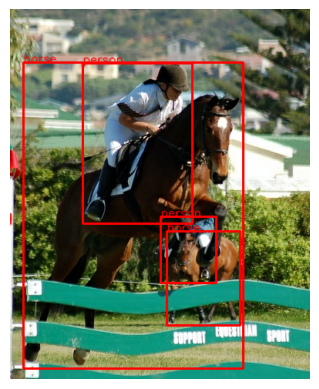

In [5]:
for example in ds_train.take(1):
    image = example['image'].numpy() / 255.0
    boxes = example['objects']['bbox'].numpy()
    labels = example['objects']['label'].numpy()
    labels = [ds_info.features['objects']['label'].int2str(int(l)) for l in labels]
    draw_bounding_boxes(image, boxes, labels)
    break

In [7]:
# Define a CNN model based on the pre-trained model
transfer_cnn_model = load_pretrained_model(IMG_HEIGHT,IMG_WIDTH,3)
transfer_cnn_model.compile(optimizer='adam',
                           loss={'bbox': 'mse', 'class': 'sparse_categorical_crossentropy'},
                           metrics={'bbox': 'mse', 'class': 'accuracy'})

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
transfer_cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 20)        │      1,300 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_output (Dense) │ (None, 4)         │        260 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,603,992 (9.93 MB)

 Trainable params: 346,008 (1.32 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
IoU: 0.0
Predicted Class: car | True Class: dog


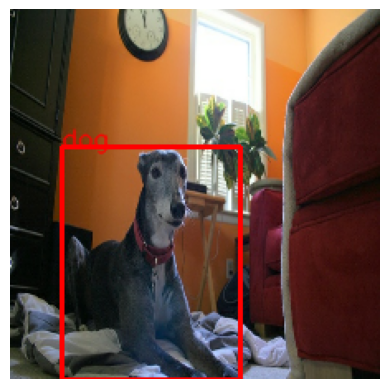

In [10]:
# Example evaluation: With Transfer Learning
for example in ds_test.take(1):
    image = tf.image.resize(example['image'], (IMG_HEIGHT, IMG_WIDTH)) / 255.0
    true_box = example['objects']['bbox'].numpy()[0]
    true_label = example['objects']['label'].numpy()[0]
    true_label = ds_info.features['objects']['label'].int2str(int(true_label))

    transfer_pred = transfer_cnn_model.predict(tf.expand_dims(image, axis=0))
    transfer_pred_box = transfer_pred[1]
    transfer_pred_class = np.argmax(transfer_pred[0])
    transfer_pred_label = ds_info.features['objects']['label'].int2str(int(transfer_pred_class))

    print("IoU:", iou(transfer_pred_box[0], true_box))
    print("Predicted Class:", transfer_pred_label, "| True Class:", true_label)
    draw_bounding_boxes(image.numpy(), [transfer_pred_box[0], true_box], [transfer_pred_label, true_label])
    break

In [12]:
# Apply initial preprocessing to individual samples
train_ds_processed = ds_train.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_processed = ds_test.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)

In [13]:
# Filter out samples with no objects (ensures labels[0] and bboxes[0] are valid)
train_ds_filtered = train_ds_processed.filter(lambda img, bboxes, labels: tf.shape(bboxes)[0] > 0)
val_ds_filtered = val_ds_processed.filter(lambda img, bboxes, labels: tf.shape(bboxes)[0] > 0)

In [14]:
# Apply the formatting function to the filtered datasets before batching
train_ds_formatted_for_model = train_ds_filtered.map(format_model_inputs, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_formatted_for_model = val_ds_filtered.map(format_model_inputs, num_parallel_calls=tf.data.AUTOTUNE)

In [15]:
# --- Data Pipeline Setup (Re-defined for correctness within this cell) ---
# Set batch size (assuming BATCH_SIZE is globally defined)
BATCH_SIZE = 16

# Define padded shapes for the outputs of `format_model_inputs`
# After `format_model_inputs`, each element is:
# (image (IMG_HEIGHT, IMG_WIDTH, 3), {'class_output': scalar, 'bbox_output': [4]})
padded_shapes_final = (
    tf.TensorShape([IMG_HEIGHT, IMG_WIDTH, 3]),  # Images: fixed shape
    {
        'class_output': tf.TensorShape([]),      # Classification label: scalar
        'bbox_output': tf.TensorShape([4])       # Bounding box: fixed shape [4]
    }
)

# Define padding values (used by padded_batch, even if shapes are fixed)
padding_values_final = (
    tf.constant(0.0, dtype=tf.float32),  # Image padding value
    {
        'class_output': tf.constant(-1, dtype=tf.int64), # Label padding value (e.g., -1 for 'no object')
        'bbox_output': tf.constant(0.0, dtype=tf.float32)  # Bbox padding value (e.g., [0,0,0,0])
    }
)

# Apply padded_batch to the correctly formatted datasets
train_ds_batched = train_ds_formatted_for_model.padded_batch(
    BATCH_SIZE,
    padded_shapes=padded_shapes_final,
    padding_values=padding_values_final
).prefetch(tf.data.AUTOTUNE)

val_ds_batched = val_ds_formatted_for_model.padded_batch(
    BATCH_SIZE,
    padded_shapes=padded_shapes_final,
    padding_values=padding_values_final
).prefetch(tf.data.AUTOTUNE)

In [16]:
# --- Model Compilation and Training
transfer_cnn_model.compile(optimizer='adam',
                           loss={
                               'class_output': tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                               'bbox_output': tf.keras.losses.MeanSquaredError()
                           },
                           metrics={
                                  'class_output': ['accuracy'],
                                  'bbox_output': []
                           }
                           )

In [17]:
# Callback functions to track training
run_file = 00
checkpoint_path = "transfer_cnn_model_run_"+str(run_file)+"/cp.ckpt.checkpoint.weights.h5"
checkpoint_dir = os.path.dirname(checkpoint_path)
checkpoint = ModelCheckpoint(filepath=checkpoint_path, save_weights_only=True, monitor='val_bbox_output_loss', save_best_only=True, mode='min')

early_stopping = EarlyStopping(monitor='val_bbox_output_loss', mode='min', patience=5, restore_best_weights=True)

In [18]:
# Train the model with the correctly formatted and batched datasets
EPOCHS = 5
history = transfer_cnn_model.fit(train_ds_batched,
                                 epochs=EPOCHS,
                                 validation_data=val_ds_batched,
                                 callbacks=[early_stopping, checkpoint])

Epoch 1/5
    157/Unknown 121s 692ms/step - bbox_output_loss: 0.1777 - class_output_accuracy: 0.4052 - class_output_loss: 2.1354 - loss: 2.3131

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


157/157 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - bbox_output_loss: 0.0910 - class_output_accuracy: 0.5298 - class_output_loss: 1.6615 - loss: 1.7689 - val_bbox_output_loss: 0.0515 - val_class_output_accuracy: 0.6496 - val_class_output_loss: 1.1877 - val_loss: 1.2442
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - bbox_output_loss: 0.0440 - class_output_accuracy: 0.7329 - class_output_loss: 0.8452 - loss: 0.8981 - val_bbox_output_loss: 0.0477 - val_class_output_accuracy: 0.6573 - val_class_output_loss: 1.1953 - val_loss: 1.2482
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - bbox_output_loss: 0.0353 - class_output_accuracy: 0.8105 - class_output_loss: 0.6012 - loss: 0.6429 - val_bbox_output_loss: 0.0473 - val_class_output_accuracy: 0.6595 - val_class_output_loss: 1.2084 - val_loss: 1.2612
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - bbox_output_loss: 0.0305 - class_output_accuracy: 0.8653 - class_output_loss: 0.4322 - loss: 0.4675 - val_bbox_output_loss: 0.0488 - val_cla

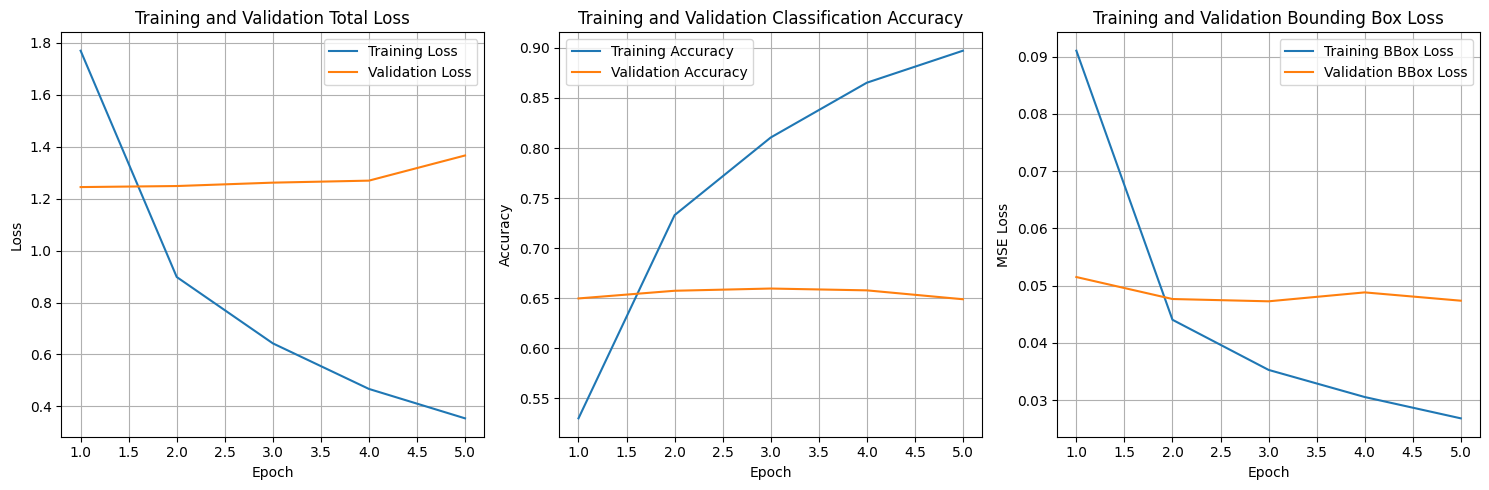

In [19]:
# Access the history object
history_dict = history.history

# Extract metrics for plotting
loss = history_dict['loss']
val_loss = history_dict['val_loss']

class_acc = history_dict['class_output_accuracy']
val_class_acc = history_dict['val_class_output_accuracy']

bbox_loss = history_dict['bbox_output_loss']
val_bbox_loss = history_dict['val_bbox_output_loss']

epochs_range = range(1, len(loss) + 1)

# Create a figure with subplots
plt.figure(figsize=(15, 5))

# Subplot 1: Total Loss
plt.subplot(1, 3, 1)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Classification Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, class_acc, label='Training Accuracy')
plt.plot(epochs_range, val_class_acc, label='Validation Accuracy')
plt.title('Training and Validation Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Subplot 3: Bounding Box Regression Loss
plt.subplot(1, 3, 3)
plt.plot(epochs_range, bbox_loss, label='Training BBox Loss')
plt.plot(epochs_range, val_bbox_loss, label='Validation BBox Loss')
plt.title('Training and Validation Bounding Box Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Class Names: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


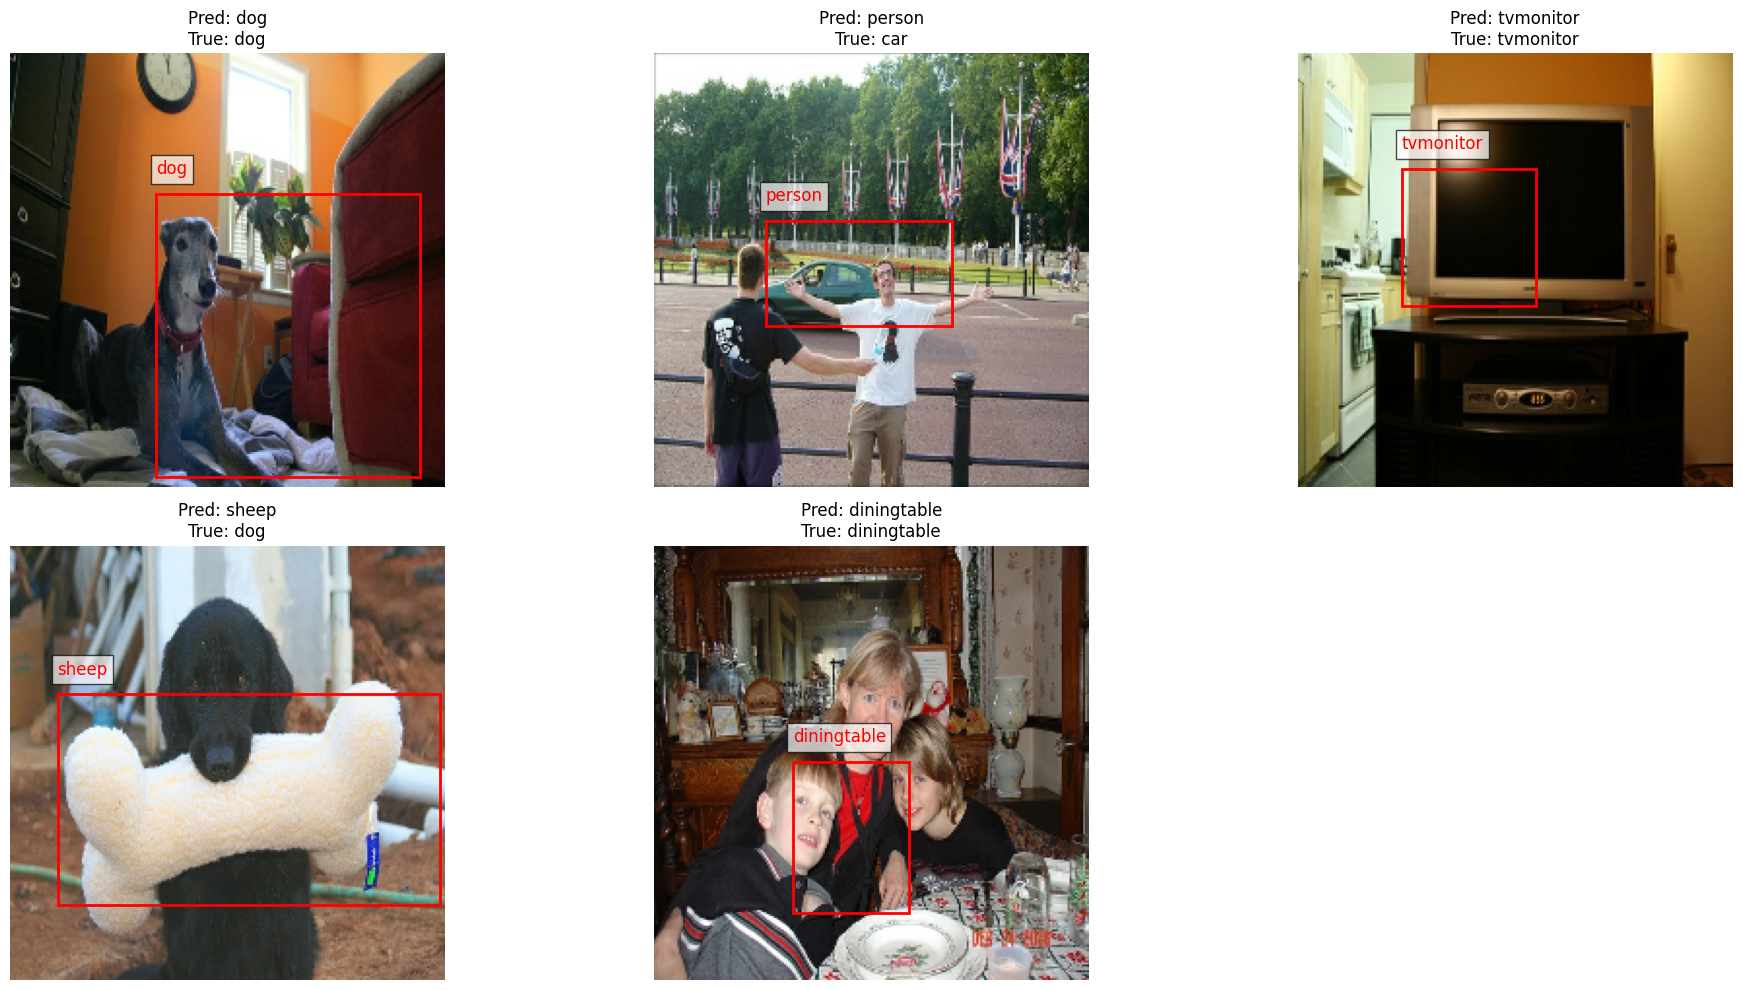

In [20]:
# Obtain a batch of images and their corresponding true labels and bounding boxes
# from the val_ds_batched dataset.
# Note: val_ds_batched yields (image, {'class_output': label, 'bbox_output': bbox})
for images, targets in val_ds_batched.take(1):
    batch_images = images
    batch_true_labels = targets['class_output']
    batch_true_bboxes = targets['bbox_output']

# Use the trained model to make predictions
predictions = transfer_cnn_model.predict(batch_images)
predicted_class_probs = predictions[0]
predicted_bboxes = predictions[1]

# Get the class names
class_names = ds_info.features['objects']['label'].names
print(f"Class Names: {class_names}")

# Iterate through a few (e.g., 5) images in the batch to visualize their predictions
num_images_to_display = 5

plt.figure(figsize=(20, 10))

for i in range(num_images_to_display):
    # Convert the image tensor back to a displayable format
    image_display = batch_images[i].numpy() # Already normalized [0,1]

    # Get predicted class probabilities and bounding box coordinates for the current image
    pred_probs = predicted_class_probs[i]
    pred_bbox = predicted_bboxes[i]

    # Determine the predicted class label
    predicted_class_id = np.argmax(pred_probs)
    predicted_class_name = class_names[predicted_class_id]

    # Denormalize the predicted bounding box coordinates
    # pred_bbox is [ymin, xmin, ymax, xmax] in normalized [0,1]
    ymin, xmin, ymax, xmax = pred_bbox
    xmin_pixel = int(xmin * IMG_WIDTH)
    ymin_pixel = int(ymin * IMG_HEIGHT)
    xmax_pixel = int(xmax * IMG_WIDTH)
    ymax_pixel = int(ymax * IMG_HEIGHT)

    width_pixel = xmax_pixel - xmin_pixel
    height_pixel = ymax_pixel - ymin_pixel

    # Get true label and bbox for comparison (if available and not padding)
    true_label_id = batch_true_labels[i].numpy()
    true_bbox = batch_true_bboxes[i].numpy()

    true_class_name = "N/A (padding)"
    if true_label_id != -1: # Check for padding value
        true_class_name = class_names[true_label_id]

    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    plt.imshow(image_display)
    plt.axis('off')

    # Draw the predicted bounding box
    rect = plt.Rectangle((xmin_pixel, ymin_pixel),
                         width_pixel, height_pixel,
                         linewidth=2, edgecolor='r', facecolor='none')
    plt.gca().add_patch(rect)

    # Add the predicted class label as text
    plt.text(xmin_pixel, ymin_pixel - 10, predicted_class_name,
             color='r', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

    # Add title for comparison
    plt.title(f"Pred: {predicted_class_name}\nTrue: {true_class_name}")

plt.tight_layout()
plt.show()